
# TRNG Approach A - RTC vs TCC Jitter on XMEGA (CW303)
Quick testbench to compile, flash, collect, and evaluate random bits from a
TRUERA-style TRNG adapted to the ATxmega128D4 on ChipWhisperer CW303.

> Duplicate this notebook to create Approach B/C/D (e.g., ADC noise, ring oscillators, SRAM startup), changing only the acquisition cell title & acquisition code. Each notebook keeps the same test battery, so you can compare results apples-to-apples.



## Requirements
- ChipWhisperer installed (`pip install chipwhisperer`), hardware connected (CW-Lite/NAE-Scope + CW303 XMEGA target).
- Your TRNG firmware placed in `FW_DIR` (below) and builds with `make PLATFORM=CW303` to create `.hex`.
- The firmware implements SimpleSerial command: `r<N>` -> returns `ceil(N/8)` bytes (MSB-first packing).

If you use my minimal no-FIFO firmware from chat, you're good.


## 1) Build firmware

In [5]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial)
scope.default_setup()

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 1573875                   to 23769344                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

In [3]:
%%bash
make PLATFORM=CWLITEXMEGA SOURCE=debug_osc_trng.c

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEXMEGA with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
avr-gcc (GCC) 7.3.0
Copyright (C) 2017 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEXMEGA 
.
Compiling:
-en     debug_osc_trng.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal/hal.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/XMEGA_AES_driver.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/uart.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/usart_driver.c ...
-e Done!
.
Compiling:
-en     ../../../firmware

## 2) Program target (XMEGA on CW303)

In [6]:
hex = "output-CWLITEXMEGA.hex"
cw.program_target(scope, cw.programmers.XMEGAProgrammer, hex)

XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 4305 bytes


## 3) Acquire random bits - Approach A: RTC vs TCC jitter

In [7]:
target.flush()
target.simpleserial_write('u', b'')
resp = target.simpleserial_read('d', 4)
print("Resp:", resp.hex() if resp else None)


Resp: 0d01030d


In [10]:
target.simpleserial_write('x', b'')
resp = target.simpleserial_read('x', 2)
print("Resp:", resp.hex() if resp else None)

Resp: 5701


In [514]:

target.simpleserial_write('o', b'')
resp = target.simpleserial_read('x', 2)
print("Resp:", resp.hex() if resp else None)


Resp: a37e


In [37]:
target.simpleserial_write('a', b'')
resp = target.simpleserial_read('x', 1,timeout=2000)  
print("Resp:", resp.hex() if resp else None)

Resp: 15


In [2]:
f_rtc = 32.768e3
t_rtc = 1 / f_rtc
f_tcc0 = 32e6
t_tcc0 = 1 / f_tcc0

print(log2(1*t_rtc / t_tcc0))

NameError: name 'log2' is not defined

## senity check

Collected 10000 random bytes
Bit biases (probability of '1' for each bit position):
Bit 0: 0.3934
Bit 1: 0.3981
Bit 2: 0.5029
Bit 3: 0.4877
Bit 4: 0.4999
Bit 5: 0.4982
Bit 6: 0.5008
Bit 7: 0.5060


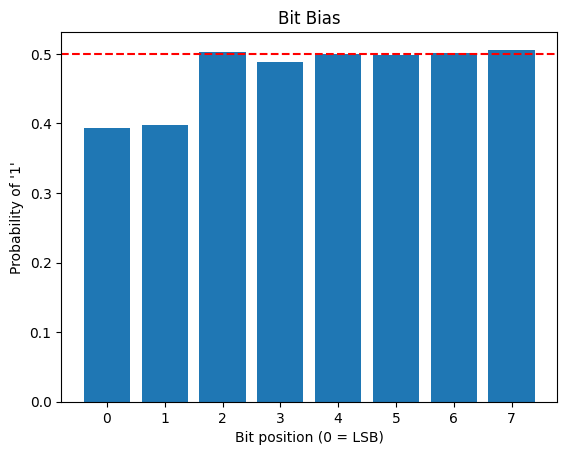


Byte distribution stats:
Min prob: 0.0015, Max prob: 0.0080, Expected = 0.0039


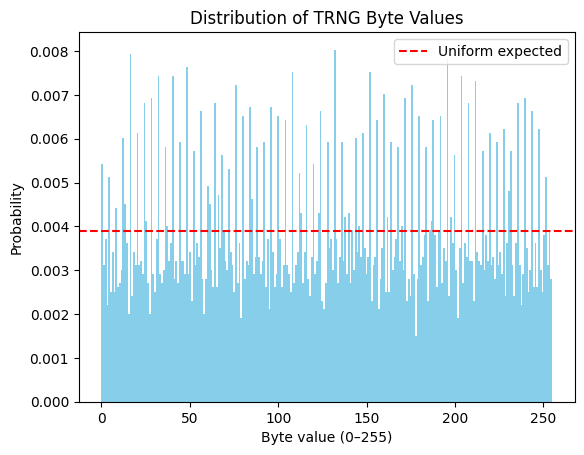

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 1. Collect random bytes from target =====
N = 10000   # number of random bytes to collect
rand_bytes = []

for _ in range(N):
    target.simpleserial_write('a', b'')              # request one byte
    resp = target.simpleserial_read('x', 1, timeout=2000)
    if resp:
        rand_bytes.append(resp[0])

rand_bytes = np.array(rand_bytes, dtype=np.uint8)

print(f"Collected {len(rand_bytes)} random bytes")

# ===== 2. Bit bias analysis =====
bit_counts = np.zeros(8)
for i in range(8):
    bit_counts[i] = np.sum((rand_bytes >> i) & 1)

bit_bias = bit_counts / len(rand_bytes)  # fraction of 1s per bit

print("Bit biases (probability of '1' for each bit position):")
for i, p in enumerate(bit_bias):
    print(f"Bit {i}: {p:.4f}")

plt.bar(range(8), bit_bias)
plt.axhline(0.5, color='r', linestyle='--')
plt.xlabel("Bit position (0 = LSB)")
plt.ylabel("Probability of '1'")
plt.title("Bit Bias")
plt.show()

# ===== 3. Byte value distribution =====
values, counts = np.unique(rand_bytes, return_counts=True)
probs = counts / len(rand_bytes)

print("\nByte distribution stats:")
print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected = {1/256:.4f}")

plt.hist(rand_bytes, bins=256, range=(0, 255), density=True, color='skyblue')
plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
plt.xlabel("Byte value (0–255)")
plt.ylabel("Probability")
plt.title("Distribution of TRNG Byte Values")
plt.legend()
plt.show()


## 4) Quick tests & metrics

## 5) Save a one-page text report (quick summary)

In [ ]:

report = f"""TRNG Approach A - RTC vs TCC jitter (XMEGA CW303)
Bits collected: {bits.size}

Frequency (monobit):
  ones = {freq['ones']}, p_hat = {freq['p_hat']:.6f}, z = {freq['z']:.3f}

Runs test:
  runs = {runs.get('runs')}, expected = {runs.get('expected', float('nan')):.2f},
  z = {runs.get('z', float('nan')):.3f}, p = {runs.get('p_value', float('nan')):.4f}

Entropy:
  Shannon entropy/bit (via bytes) = {Hperbit:.6f}
  Min-entropy/bit (bit MCV)       = {Hmin:.6f}

Notes:
  - This is a quick sanity battery; not a replacement for full NIST STS.
  - Duplicate this notebook for other approaches (ADC noise, RO, SRAM) and re-run.
"""

path = f"/mnt/data/{SAVE_PREFIX}_summary.txt"
with open(path, "w") as f:
    f.write(report)
print(report)
print("Saved report:", path)


## 6) Cleanup / disconnect (optional)

In [ ]:

try:
    target.dis()
except Exception:
    pass
try:
    scope.dis()
except Exception:
    pass
print("Disconnected.")
